# Bank Telemarketing Data Preparation Notebook
This notebook handles encoding, dimension reduction, influential point extraction, and feature selection to prepare the dataset for classification/regression.

Cleaning & Transform directly on `df`, Feature selected on `X`, Encoded and scaled onto `X_encoded_scaled` and mapped into `final_df` and exported as `master_features.csv` 


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [25]:
df = pd.read_csv('./data/dataset.csv') #ownself edit

In [26]:
# Display initial shape
print(f"Original Dataset Shape: {df.shape}")

# Handle 'duration': Drop it to prevent target leakage. 
# In real-world telemarketing, you cannot know the call duration before you make the call.
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print("Dropped 'duration' to prevent target leakage.")

# Handle 'pdays' anomaly (999 means client was not previously contacted)
# We will create a binary flag for 'contacted_before' and replace 999 with 0 in pdays.
df['contacted_before'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)

# Ensure target is binary
y = df['y']
if y.dtype == 'object' or y.dtype == 'O':
    y = (y == 'yes').astype(int)

df['y_bin'] = y

Original Dataset Shape: (41188, 20)
Dropped 'duration' to prevent target leakage.


## 2. Demographic Transformations

#### Age → `age_grouped`
Continuous age is binned into four groups to capture a **non-monotonic U-shaped** relationship with conversion. Both young and retired clients convert at much higher rates than working-age adults.

| Bin | Label | Conversion Rate |
|---|---|---|
| ≤25 | Student/Young | 20.95% |
| 26–45 | Working Adult | 10.23% |
| 46–60 | Senior Working | 9.56% |
| >60 | Retired | 45.49% |

Because there is no defensible linear order between groups, `age_group` is **OHE encoded** in part 4.

#### Job → `job_grouped`
Eleven raw job categories are collapsed into four economically coherent groups:

| Group | Members |
|---|---|
| `blue_collar` | blue-collar, technician, services |
| `white_collar` | management, admin., entrepreneur |
| `not_working` | student, retired, unemployed |
| `other` | housemaid, self-employed, unknown |

No directional order exists between groups, so `job_grouped` is **OHE encoded** in §4.

In [27]:
# Age Binning (Capturing the U-Shape relationship)
bins = [0, 25, 45, 60, 120]
labels = ['Student/Young (<25)', 'Working Adult (26-45)', 'Senior Working (46-60)', 'Retired (>60)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Job Grouping by economic similarity
job_mapping = {
    'student': 'not_working', 'retired': 'not_working', 'unemployed': 'not_working',
    'management': 'white_collar', 'admin.': 'white_collar', 'entrepreneur': 'white_collar',
    'blue-collar': 'blue_collar', 'technician': 'blue_collar', 'services': 'blue_collar',
    'housemaid': 'other', 'self-employed': 'other', 'unknown': 'other'
}
df['job_grouped'] = df['job'].map(job_mapping)


#### Education → `education_ordinal`
Three `basic.3y/6y/9y` sub-levels are first consolidated to `basic` to reduce sparsity, then the grouped variable is mapped to an integer using the monotonically increasing ladder:

```
illiterate=0 · unknown=1 · basic=2 · high.school=3 · professional.course=4 · university.degree=5
```

Higher education correlates with higher financial sophistication and conversion rates, making **ordinal encoding** the correct choice.

In [28]:
# 2.2 Education Ordinal Encoding & Grouping
# Combine basic education into one category to reduce sparsity
df['education_grouped'] = df['education'].replace({
    'basic.4y': 'basic',
    'basic.6y': 'basic',
    'basic.9y': 'basic'
})

# Create an ordinal mapping (assuming higher education correlates with different financial behavior)
education_map = {
    'illiterate': 0,
    'unknown': 1,
    'basic': 2,
    'high.school': 3,
    'professional.course': 4,
    'university.degree': 5
}
df['education_ordinal'] = df['education_grouped'].map(education_map)

## 3. Campaign Transformations
_of all clients who received exactly X calls, what fraction subscribed?_
#### Campaign contacts → `Campaign_ordinal`
Contacts are capped and binned (`1`, `2`, `3`, `4`, `5+`) then mapped to integers `0–4`. The relationship with conversion is **monotonically decreasing** — each additional call reflects fatigue and diminishing returns. (see section 7. for proof)

| Bin | Conversion Rate |
|---|---|
| 1 call | 13.04% |
| 2 calls | 11.46% |
| 3 calls | 10.75% |
| 4 calls | 9.39% |
| 5+ calls | 6.14% |

#### Previous contacts → `previous_ordinal`
Grouped into `0`, `1`, `2+` and mapped to integers `0–2`. The relationship is **monotonically increasing** — prior contact signals a warmer lead. (see section 7. for proof)

| Bin | Conversion Rate |
|---|---|
| 0 | 8.83% |
| 1 | 21.20% |
| 2+ | 50.00% |


In [29]:
# 3.1 Campaign Fatigue (Capping/Binning the number of contacts)
# Anything above 5 contacts usually yields diminishing returns
df['campaign_binned'] = df['campaign'].apply(lambda x: str(x) if x <= 4 else '5+')

# Ordinal encode: monotonically DECREASING — more calls → fatigue → lower conversion
campaign_order = {'1': 0, '2': 1, '3': 2, '4': 3, '5+': 4}
df['campaign_ordinal'] = df['campaign_binned'].map(campaign_order)

# 3.2 Previous Contacts
# Most are 0. We'll group them into 0, 1, and 2+
df['previous_binned'] = df['previous'].apply(lambda x: str(x) if x <= 1 else '2+')

# Ordinal encode: monotonically INCREASING — more prior contacts → warmer lead → higher conversion
previous_order = {'0': 0, '1': 1, '2+': 2}
df['previous_ordinal'] = df['previous_binned'].map(previous_order)

# Interaction: contacted before AND had multiple prior contacts = warmest lead
df['prior_engagement'] = df['contacted_before'] * df['previous_ordinal']

## 4. Feature Engineering & Selection
All superseded source and intermediate columns are explicitly dropped from `X` **before** any encoding runs

| Dropped | Reason | Replacement |
|---|---|---|
| `age` | raw numeric | `age_group` (OHE) |
| `campaign` | raw numeric | `campaign_ordinal` |
| `campaign_binned` | string intermediate | `campaign_ordinal` |
| `previous` | raw numeric | `previous_ordinal` |
| `previous_binned` | string intermediate | `previous_ordinal` |
| `pdays` | recoded in §1 | `contacted_before` |
| `job` | raw 11-class string | `job_grouped` (OHE) |
| `education` | raw string | `education_ordinal` |
| `education_grouped` | string intermediate | `education_ordinal` |

`pd.get_dummies(drop_first=True)` is then applied **only** to the remaining nominal categoricals: `age_group`, `job_grouped`, `marital`, `month`, `contact`, `day_of_week`, `poutcome`, `housing`, `loan`, `default`.

The three ordinal integer columns (`education_ordinal`, `campaign_ordinal`, `previous_ordinal`) are already numeric and pass through untouched.

**Shape after §4:** 41,188 × 35

In [30]:
# Separate the target variable
y = df['y_bin']
# Drop target-related columns from features
X = df.drop(columns=['y', 'y_bin'])

In [31]:
# ── Drop all superseded source and intermediate columns ──────────────────────
# Each dropped column has an engineered replacement already in X:
#   age               → age_group          (OHE, U-shape non-monotonic)
#   campaign          → campaign_ordinal   (ordinal, monotonic decreasing)
#   campaign_binned   → campaign_ordinal   (string intermediate, no longer needed)
#   previous          → previous_ordinal   (ordinal, monotonic increasing)
#   previous_binned   → previous_ordinal   (string intermediate, no longer needed)
#   pdays             → contacted_before   (binary flag)
#   job               → job_grouped        (OHE, no directional order)
#   education         → education_ordinal  (ordinal, monotonic increasing)
#   education_grouped → education_ordinal  (string intermediate, no longer needed)
SUPERSEDED = [
    'age', 'campaign', 'campaign_binned',
    'previous', 'previous_binned',
    'pdays',
    'job', 'education', 'education_grouped',
]
X = X.drop(columns=[c for c in SUPERSEDED if c in X.columns])

In [32]:
# ── One-Hot Encode only nominal / non-ordinal categoricals ───────────────────
# Ordinal features (education_ordinal, campaign_ordinal, previous_ordinal)
# are already integer-valued and pass through untouched.
# OHE targets: age_group (U-shape), job_grouped (no order),
#              marital, month, contact, day_of_week, poutcome, housing, loan, default
ohe_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=ohe_cols, drop_first=False)
print(f"Shape after encoding categorical features: {X_encoded.shape}")

Shape after encoding categorical features: (41188, 42)


/var/folders/k7/th6vsvfs5v1cs08pj3yfjkh40000gp/T/ipykernel_74343/2862682638.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ohe_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


## 5. Outlier/ Influential Points

`IsolationForest` (100 trees, `contamination=0.05`, `random_state=42`) is fit on the full encoded matrix. The result is an additional column `is_influential_outlier` binary flag (0/1).

- **2,060 rows flagged** as anomalous (~5% of dataset)
- Rows are **retained** — the flag allows downstream models to weight or filter them selectively.

In [33]:
# We use Isolation Forest to detect multivariate outliers
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X_encoded)

# -1 indicates an outlier/influential point, 1 indicates an inlier
X_encoded['is_influential_outlier'] = (outlier_labels == -1).astype(int)

print(f"Detected {X_encoded['is_influential_outlier'].sum()} influential/anomalous points.")

Detected 2060 influential/anomalous points.


## 6. Dimensionality Reduction on Socioeconomic Indicators
The five macroeconomic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) are highly collinear. I decide to standardise and reduce them into to a single component `macro_economic_pca_1` (via PCA).

- **PC1 explains 69.42% of variance** across the five indicators.
- Original five columns are dropped; `macro_economic_pca_1` takes their place.

In [34]:
X_encoded_scaled = X_encoded.copy()

In [35]:
socioeconomic_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Ensure these columns exist in our numerical list
existing_socio_cols = [col for col in socioeconomic_cols if col in X_encoded_scaled.columns]

# Scale the socioeconomic features
scaler = StandardScaler()
socio_scaled = scaler.fit_transform(X_encoded_scaled[existing_socio_cols])

# Apply PCA
pca = PCA(n_components=1)  # Reduce to 1 principal component
macro_economic_component = pca.fit_transform(socio_scaled)

print(f"Variance explained by 1st Principal Component: {pca.explained_variance_ratio_[0]:.4f}")

# Replace original socioeconomic columns with the new PCA component
X_encoded_scaled = X_encoded_scaled.drop(columns=existing_socio_cols)
X_encoded_scaled['macro_economic_pca_1'] = macro_economic_component

Variance explained by 1st Principal Component: 0.6942


#### StandardScaler
Applied only to columns where `nunique() > 2`, which excludes OHE dummy columns (already binary `0/1`) and `is_influential_outlier`. This covers the true continuous numerics and the ordinal integers (`education_ordinal`, `campaign_ordinal`, `previous_ordinal`).

In [36]:
skip_scaling = ['default', 'housing', 'loan', 'is_influential_outlier', 'contacted_before']

# Scale the remaining numerical features to ensure algorithms converge quickly
remaining_numeric = [col for col in X_encoded_scaled.select_dtypes(exclude=['object', 'category']).columns
                     if col not in existing_socio_cols 
                     and col not in skip_scaling
                     and X_encoded_scaled[col].nunique() > 2   # exclude binary/dummy columns
                     ]
X_encoded_scaled[remaining_numeric] = scaler.fit_transform(X_encoded_scaled[remaining_numeric])

In [37]:
X_encoded_scaled.info() #this exclude y_target

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   default                           41188 non-null  int64  
 1   housing                           41188 non-null  int64  
 2   loan                              41188 non-null  int64  
 3   contacted_before                  41188 non-null  int64  
 4   education_ordinal                 41188 non-null  float64
 5   campaign_ordinal                  41188 non-null  float64
 6   previous_ordinal                  41188 non-null  float64
 7   prior_engagement                  41188 non-null  float64
 8   marital_divorced                  41188 non-null  bool   
 9   marital_married                   41188 non-null  bool   
 10  marital_single                    41188 non-null  bool   
 11  marital_unknown                   41188 non-null  bool   
 12  contact_cellula

## 7. Conversion Rates for Stratification
To check the variance of the data, conversion-rate tables are printed for `education_grouped`, `campaign_binned`, and `previous_binned` on the pre-scaled `X_encoded`

`age_group_label` `job_grouped_label` not checked for conversion as its one-hot encoded, but can be maybe investiagated elsewhere during model building

In [38]:
X_check = X_encoded.assign(target_y=y.values)  

In [39]:
def print_conversion_rates(column):
    summary = X_check.groupby(column, observed=False)['target_y'].agg(['mean', 'count'])
    summary = summary.rename(columns={'mean': 'Conversion Rate (%)', 'count': 'Total Contacts'})
    summary['Conversion Rate (%)'] = (summary['Conversion Rate (%)'] * 100).round(2)
    print(f"--- Conversion Rates by {column} ---\n{summary}\n")

# Ordinal: clean integers, group directly
print_conversion_rates('education_ordinal')   # 0–5
print_conversion_rates('campaign_ordinal')    # 0–4
print_conversion_rates('previous_ordinal')    # 0–2

--- Conversion Rates by education_ordinal ---
                   Conversion Rate (%)  Total Contacts
education_ordinal                                     
0                                22.22              18
1                                14.50            1731
2                                 8.70           12513
3                                10.84            9515
4                                11.35            5243
5                                13.72           12168

--- Conversion Rates by campaign_ordinal ---
                  Conversion Rate (%)  Total Contacts
campaign_ordinal                                     
0                               13.04           17642
1                               11.46           10570
2                               10.75            5341
3                                9.39            2651
4                                6.14            4984

--- Conversion Rates by previous_ordinal ---
                  Conversion Rate (%)  Total

## 8. Exporting the Master Dataset

In [40]:
final_df = X_encoded_scaled.copy()
final_df['target_y'] = y

print(f"Remaining feature count (excluding target): {final_df.shape[1] - 1}")
print(f"Final shape: {final_df.shape}")

Remaining feature count (excluding target): 39
Final shape: (41188, 40)


In [41]:
final_df.head(5) # check out Data Wrangler add-on in VSC

,default,housing,loan,contacted_before,education_ordinal,campaign_ordinal,previous_ordinal,prior_engagement,marital_divorced,marital_married,...,age_group_Working Adult (26-45),age_group_Senior Working (46-60),age_group_Retired (>60),job_grouped_blue_collar,job_grouped_not_working,job_grouped_other,job_grouped_white_collar,is_influential_outlier,macro_economic_pca_1,target_y
0,0,0,0,0,-1.026365,-0.873122,-0.374858,-0.184278,False,True,...,False,True,False,False,False,True,False,0,0.701158,0
1,-1,0,0,0,-0.254069,-0.873122,-0.374858,-0.184278,False,True,...,False,True,False,True,False,False,False,0,0.701158,0
2,0,1,0,0,-0.254069,-0.873122,-0.374858,-0.184278,False,True,...,True,False,False,True,False,False,False,0,0.701158,0
3,0,0,0,0,-1.026365,-0.873122,-0.374858,-0.184278,False,True,...,True,False,False,False,False,False,True,0,0.701158,0
4,0,0,1,0,-0.254069,-0.873122,-0.374858,-0.184278,False,True,...,False,True,False,True,False,False,False,0,0.701158,0


In [ ]:
# Save to CSV for downstream classifier/regressor models
output_filename = './data/master_features.csv'
final_df.to_csv(output_filename, index=False)

print(f"Dataset successfully transformed and saved to '{output_filename}'.")

Dataset successfully transformed and saved to 'data/master_features.csv'.


## 9. Feature Extraction

To reduce data dimensionality, reduce complexity and improve interpretability, we will adopt a Pipeline where we use PCA for preprocessing and then a Decision Tree (DT) to extract key features to feed into our models. We use PCA to reduce noise and dimension to simplify the data for the DT.

In [5]:
df = pd.read_csv('../data/master_features.csv')
X = df.drop(columns=['target_y'])
y = df['target_y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1244, stratify=y)

Building Pipeline

In [6]:
pipeline = Pipeline([
    ('pca', PCA(n_components=0.95)),
    ('clf', DecisionTreeClassifier(max_depth= 5, class_weight = 'balanced', random_state=1244))
])

Cross-Validating on Training set

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1244)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-validated AUC scores: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validated AUC scores: 0.7711 ± 0.0047


In [8]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Unsuccessful', 'Successful']))
print(f"Test AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

Unsuccessful       0.95      0.81      0.87      7310
  Successful       0.29      0.63      0.40       928

    accuracy                           0.79      8238
   macro avg       0.62      0.72      0.64      8238
weighted avg       0.87      0.79      0.82      8238

Test AUC: 0.7617


Confusion Matrix

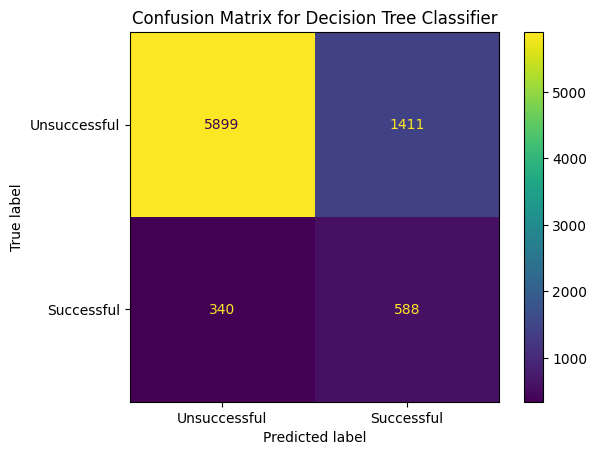

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Unsuccessful', 'Successful'])
plt.title("Confusion Matrix for Decision Tree Classifier")
plt.show()

Number of components PCA selected

In [11]:
print(pipeline.named_steps['pca'].n_components_)

20


Variance Plot

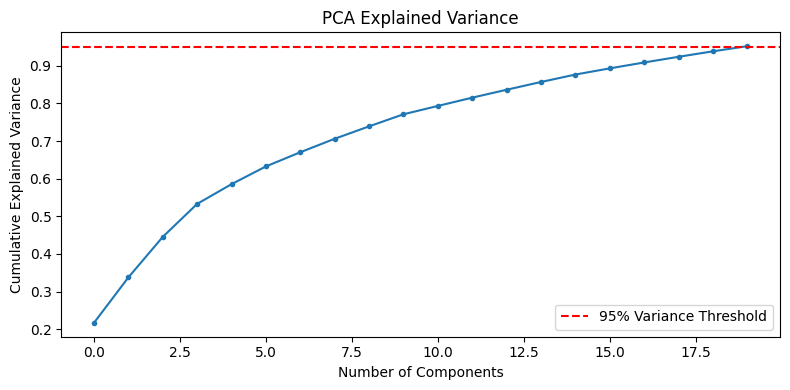

In [12]:
pca_fitted = pipeline.named_steps['pca']

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_fitted.explained_variance_ratio_), marker='o', markersize = 3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

Testing various n's for PCA

In [13]:
for n in[5, 10, 15, 20, 25, 30]:
    pipe = Pipeline([
        ('pca', PCA(n_components=n)),
        ('clf', DecisionTreeClassifier(max_depth= 5, class_weight = 'balanced', random_state=1244))
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    print(f"PCA Components: {n}, Cross-validated AUC: {score:.4f}")

PCA Components: 5, Cross-validated AUC: 0.7667
PCA Components: 10, Cross-validated AUC: 0.7666
PCA Components: 15, Cross-validated AUC: 0.7718
PCA Components: 20, Cross-validated AUC: 0.7711
PCA Components: 25, Cross-validated AUC: 0.7731
PCA Components: 30, Cross-validated AUC: 0.7778


**Looking at the AUC improvements, it is obvious PCA does not affect the Decision Tree much. Hence we shall srop PCA and implement only DT for feature selection**

In [16]:
for n in[3, 5, 10, 15, 20]:
    pipe = Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=n, class_weight='balanced', random_state=1244))
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    print(f"Max Depth: {n}, Cross-validated AUC: {score:.4f}")

Max Depth: 3, Cross-validated AUC: 0.7803
Max Depth: 5, Cross-validated AUC: 0.8000
Max Depth: 10, Cross-validated AUC: 0.7570
Max Depth: 15, Cross-validated AUC: 0.6799
Max Depth: 20, Cross-validated AUC: 0.6420


Hence best depth is 5 and we will do feature selection using that tree

In [19]:
best_depth = 5
best_tree = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=1244)
best_tree.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                             Feature  Importance
38              macro_economic_pca_1    0.735630
20                         month_may    0.142704
14                         month_apr    0.031150
22                         month_oct    0.026339
12                  contact_cellular    0.018851
7                   prior_engagement    0.018534
34           job_grouped_not_working    0.010052
5                   campaign_ordinal    0.007360
13                 contact_telephone    0.005589
25                   day_of_week_mon    0.002267
3                   contacted_before    0.001140
1                            housing    0.000196
31  age_group_Senior Working (46-60)    0.000188
32           age_group_Retired (>60)    0.000000
24                   day_of_week_fri    0.000000
33           job_grouped_blue_collar    0.000000
35                 job_grouped_other    0.000000
30   age_group_Working Adult (26-45)    0.000000
29     age_group_Student/Young (<25)    0.000000
28                  

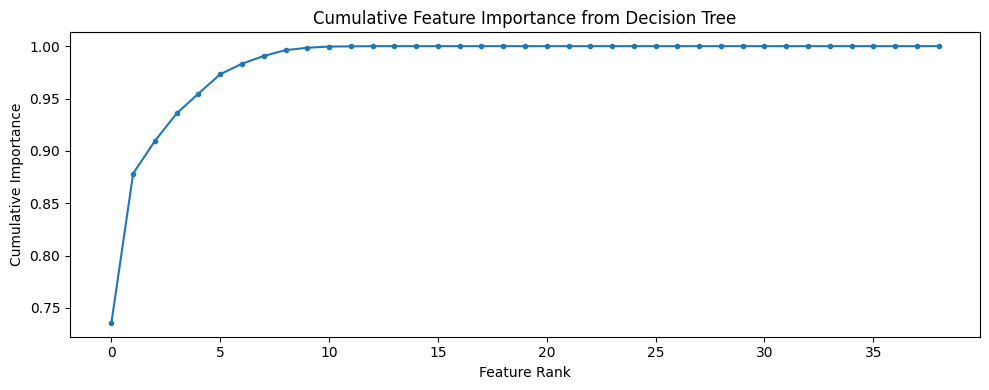

In [20]:
selected_threshold = importance_df[importance_df['Importance'] > 0.01]

importance_df['cumulative_importance'] = importance_df['Importance'].cumsum()
plt.figure(figsize=(10, 4))
plt.plot(range(len(importance_df)), importance_df['cumulative_importance'], marker='o', markersize=3)
plt.xlabel('Feature Rank')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance from Decision Tree')
plt.tight_layout()
plt.show()

Refitting using chosen Features

In [22]:
top_features = importance_df[importance_df['Importance'] > 0.01]['Feature'].tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

final_tree = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=1244)
cv_scores_top = cross_val_score(final_tree, X_train_top, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-validated AUC with top features: {cv_scores_top.mean():.4f} ± {cv_scores_top.std():.4f}")
print(f"Top features used: {top_features}")

Cross-validated AUC with top features: 0.8022 ± 0.0038
Top features used: ['macro_economic_pca_1', 'month_may', 'month_apr', 'month_oct', 'contact_cellular', 'prior_engagement', 'job_grouped_not_working']
